In [1]:
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.append("../utils/py")
import miniramses as ram

plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 180
plt.rcParams.update({
    "font.size": 14,
    "legend.fontsize": 16,
})


import sys

# Try both repo-root and analyze/ working directories.
for cand in [Path("utils/py"), Path("../utils/py")]:
    if cand.exists() and str(cand.resolve()) not in sys.path:
        sys.path.append(str(cand.resolve()))

import miniramses as ram

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11

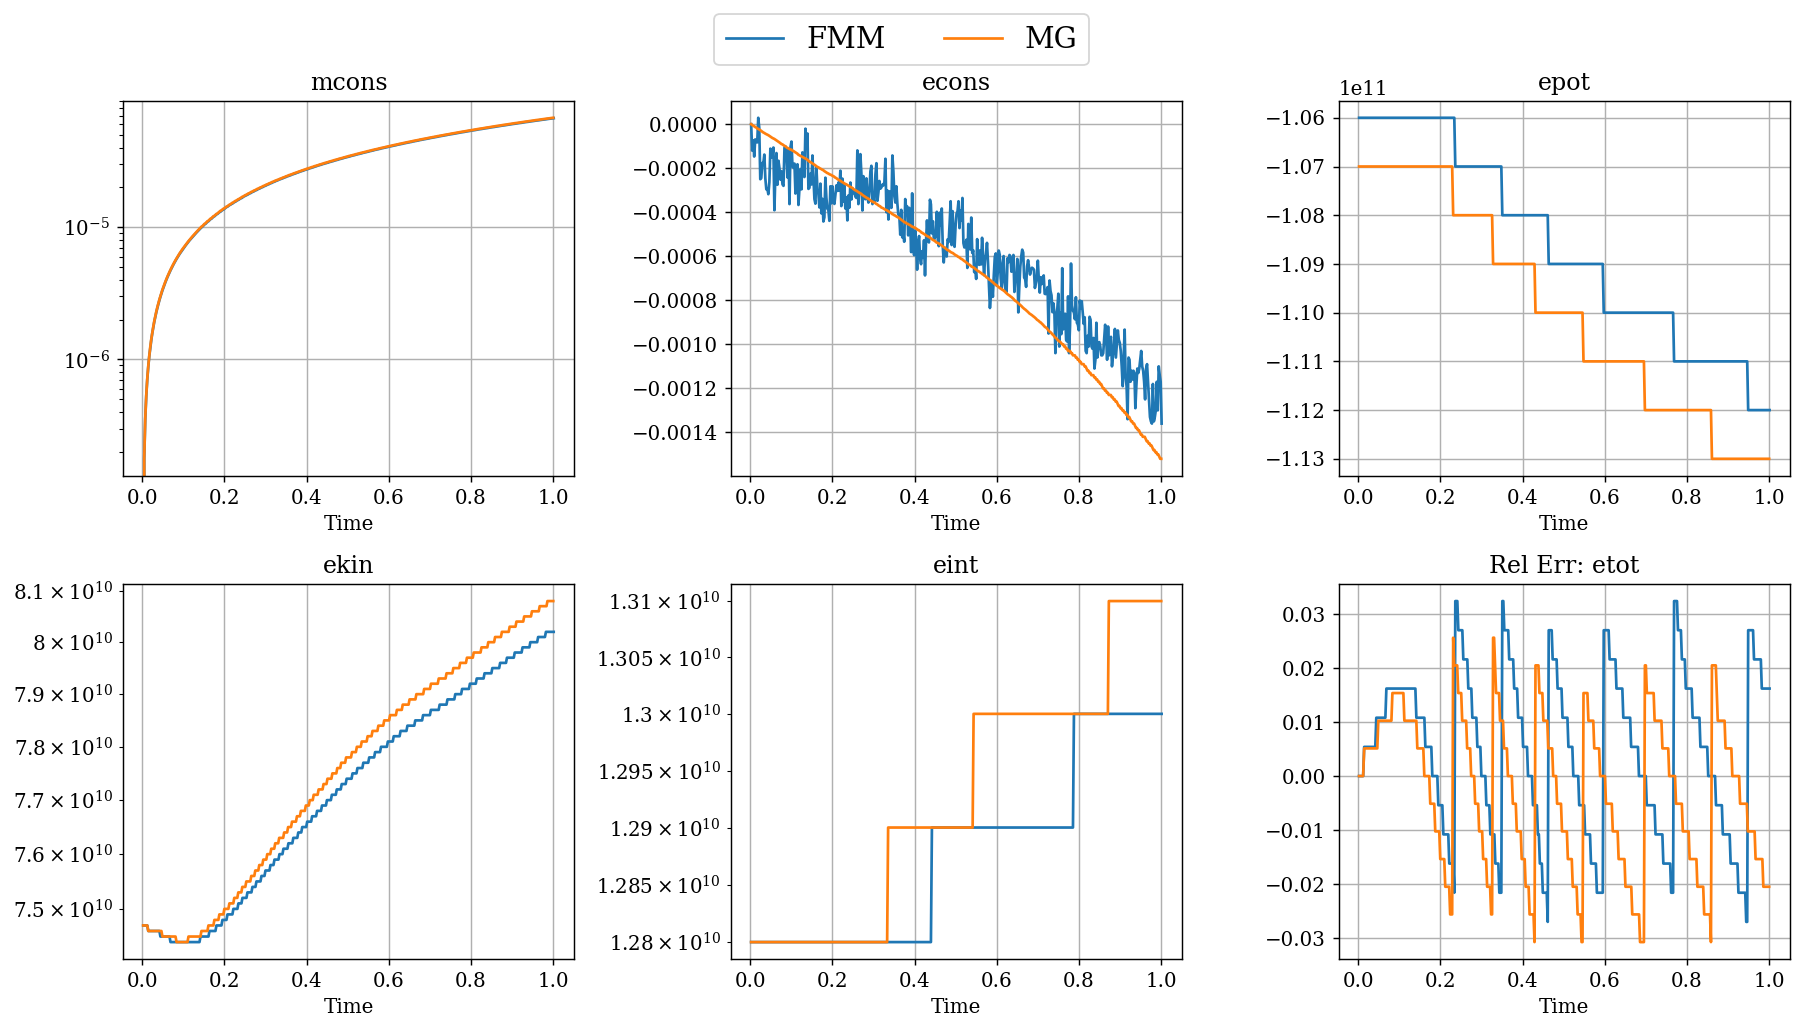

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_file(filename):
    main_pattern = re.compile(
        r"Main step=\s*(\d+)\s+"
        r"mcons=\s*([-\d.E+]+)\s+"
        r"econs=\s*([-\d.E+]+)\s+"
        r"epot=\s*([-\d.E+]+)\s+"
        r"ekin=\s*([-\d.E+]+)\s+"
        r"eint=\s*([-\d.E+]+)"
    )

    time_pattern = re.compile(
        r"Fine step=\s*\d+\s+t=\s*([-\d.E+]+)"
    )

    data = []
    current_time = None

    with open(filename, "r") as f:
        for line in f:
            # update time whenever we see it
            t_match = time_pattern.search(line)
            if t_match:
                current_time = float(t_match.group(1))

            # parse main step
            m = main_pattern.search(line)
            if m:
                step, mcons, econs, epot, ekin, eint = m.groups()
                data.append({
                    "step": int(step),
                    "time": float(current_time),  # <-- attach time here
                    "mcons": float(mcons),
                    "econs": float(econs),
                    "epot": float(epot),
                    "ekin": float(ekin),
                    "eint": float(eint),
                    "etot": float(epot) + float(ekin) + float(eint),
                })

    return pd.DataFrame(data).sort_values("step").reset_index(drop=True)


df_fmm = parse_file("/home/jl4415/mini-ramses/halo_test/halo_fmm/fmm_2707491.out")
df_mg  = parse_file("/home/jl4415/mini-ramses/halo_test/halo_mg/mg_2707491.out")


vars_list = ["mcons", "econs", "epot", "ekin", "eint", "etot"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(vars_list):
    ax = axes[i]

    if var == "etot":
        ax.plot(df_fmm["time"], (df_fmm[var]-df_fmm[var].iloc[0])/df_fmm[var].iloc[0], label="FMM")
        ax.plot(df_mg["time"], (df_mg[var]-df_mg[var].iloc[0])/df_mg[var].iloc[0], label="MG")
    else:
        ax.plot(df_fmm["time"], df_fmm[var], label="FMM")
        ax.plot(df_mg["time"], df_mg[var], label="MG")

    if var == "etot":
        ax.set_title("Rel Err: etot")
    else:
        ax.set_title(var)
        
    ax.set_xlabel("Time")
    ax.grid(True)

    # 🔑 smart scaling
    if var in ["mcons"]:
        ax.set_yscale("log")
    else:
        if (df_fmm[var] > 0).all() and (df_mg[var] > 0).all():
            ax.set_yscale("log")


# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('./fig/isolated_halo_diag.png')
plt.show()